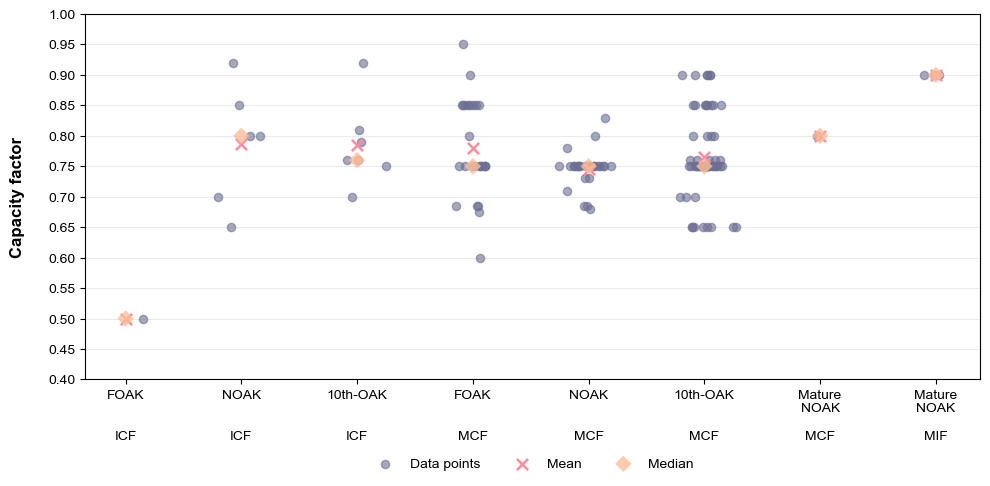

In [7]:
# === Capacity Factor by Confinement Type and Maturity ===

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# Reset defaults
plt.rcdefaults()
mpl.rcParams.update(mpl.rcParamsDefault)

# === Font setup ===
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

# === Data grouped by confinement family & maturity ===
data = {
    # --- Inertial Confinement Fusion (ICF) ---
    # LIFE & HYLIFE systems, Anklam et al. (2011), Conn et al. (1990)
    "FOAK\n\n\nICF": [
        0.50,  # LIFE1 (Anklam 2011)
    ],
         "NOAK\n\n\nICF": [
        0.65, 0.70, 0.80,  # IFE (Yamazaki 2011) range 0.65–0.85
        0.85,              # upper bound Yamazaki (2011)
             0.8, # Helsley and Burke (2014)
             0.92,  # LIFE 2 (Anklam 2011)
    ],
    "10th-OAK\n\n\nICF": [
        0.92, # LIFE 3 (Anklam 2011)
        0.76, 0.76,  # HYLIFE / CASCADE (Conn 1990)
        0.75, # (Maya 1985)
        0.7, # Blink et al. (1985)
        0.79, 0.81,  # Prometheus-L / H (Waganer 1992)
    ],
   

    # --- Magnetic Confinement Fusion (MCF) ---
"FOAK\n\n\nMCF": [
    0.60,   # Fusion intro t=0 — Tokimatsu (2002)
    0.675,  # Investment (2030) — Lako & Seebregts (1998)

    # Lerede (2023) FOAK-like setups
    0.685,  # ARC-2035 — Lerede (2023)
    0.685,  # EU-DEMO FOAK — Lerede (2023)
    0.685,  # Asian-DEMO FOAK — Lerede (2023)

    # Spears (1990) & Miller (1991)
    0.75,   # SCAN-code plant — Miller (1991)
    0.75,   # Reactor-1 — Spears (1990)
        0.75,   # Reactor-2 — Spears (1990)

    # Other FOAK concept studies

    0.75,   # SSTR-like DEMO — Oishi (2012)
    0.75,   # DEMO2 — Entler (2018)

    # Maisonnier (2007) — FOAK cases (5)
    0.75,   # PPCS A Max — Maisonnier (2007)
    0.75,   # PPCS AB Max — Maisonnier (2007)
    0.75,   # PPCS B Max — Maisonnier (2007)
    0.75,   # PPCS C Max — Maisonnier (2007)
    0.75,   # PPCS D Max — Maisonnier (2007)

    # Single count for Bednyagin & Gnansounou (2011) FOAK
    0.80,   # FOAK (scenarios A/B/C counted once) — Bednyagin & Gnansounou (2011)


    # Famà (2023) — 8 greenfield FOAK options
    0.85,   # Option 1 — Famà (2023)
    0.85,   # Option 2 — Famà (2023)
    0.85,   # Option 3 — Famà (2023)
    0.85,   # Option 4 — Famà (2023)
    0.85,   # Option 1 — Famà (2023)
    0.85,   # Option 2 — Famà (2023)
    0.85,   # Option 3 — Famà (2023)
    0.85,   # Option 4 — Famà (2023)
    
    0.90,   # CREST — Hiwatari & Goto (2019)
    0.95,   # Modular ST — Chuyanov (2017)


],
  "NOAK\n\n\nMCF": [
    # Yamazaki & Dolan (2006): Tokamak-1 / Tokamak-2 / Helical-1 / Helical-2
    0.75, 0.75, 0.75, 0.75,

    # Yamazaki et al. (2009): Tokamak / Spherical / Helical
    0.75, 0.75, 0.75,
      
    # Yamazaki et al. (2011): Tokamak-DT / Spherical-DT / Helical-DT / Tokamak Hybrid / Tokamak D-3He
    0.75, 0.75, 0.75, 0.75, 0.75,

    # Kozaki et al. (2009): LHD parameter sets
    0.68, 0.71, 0.73, 0.73,

    # Tokimatsu et al. (2002): learning improvement over time
    0.78, 0.83,

    # Jo et al. (2021): with CS and without CS
    0.75, 0.75, 0.75, 0.75,

    # Dolan et al. (2005): Heliotron NOAK
    0.75,

    # Lerede et al. (2023): ARC/EU-DEMO NOAKs
    0.685, 0.685,

    # Lindley et al. (2023): advanced-large (steady)
    0.75,

  0.80,  # Bednyagin & Gnansounou (2011): NOAK scenarios (single CF)
  ],
    
"10th-OAK\n\n\nMCF": [
    # — Delene et al. (1988): 8 distinct reactor concepts —
    0.65, 0.65, 0.65, 0.65, 0.65, 0.65,  # TOK & RFP variants at CF=0.65
    0.75, 0.75,                          # V-MHD TOK, V-DHe3 TOK at CF=0.75

    0.80,  # Bednyagin & Gnansounou (2011

    # — Conn et al. (1990): distinct reactors (CF≈0.76) —
    0.76, 0.76, 0.76, 0.76,              # ARIES-I, ARIES-II, TITAN-I (RFP), GENEROMAK LI/LI/V (RFP)

    # — Delene (1991): 2 different reactors —
    0.75, 0.75,                          # V-Li/TOK, ARIES-I

    # — Delene et al. (2001): ARIES-RS/ST envelopes —
    0.70, 0.80, 0.90,                    # ARIES-RS {min, base, max}
    0.70, 0.80, 0.90,                    # ARIES-ST {min, base, max}

    # — Dolan et al. (2005) —
    0.75,                                # ARIES-SPSS (stellarator)

    # — Drakojlovic et al. (2010) —
    0.85,                                # “New ARIES”

    # — Gi et al. (2020): (TCC framing, 10th-OAK) —
    0.90, 0.90,                          # Conventional R&D, Advanced R&D

    0.80,  # Bednyagin & Gnansounou (2011)

    # — Hender et al. (1996): three machine types —
    0.75, 0.75, 0.75,                    # Tokamak, Stellarator, Spherical Tokamak

    # — Hiwatari & Goto (2019) —
    0.90,                                # CREST (10th-OAK)

    # — Krakowski (1995): exactly 10 concepts (CF≈0.75) —
    0.75, 0.75, 0.75, 0.75, 0.75,
    0.75, 0.75, 0.75, 0.75, 0.75,        # PULSAR-I, CSR, HELIAC, HF-Stell., TITAN-I, TITAN-II,
                                         # ARIES-III, ARIES-II*, ARIES-II, ARIES-IV

    # — Lindley et al. (2023) —
    0.75,                          #  advanced-large (steady)

    # lee (1987)
    0.7,

    # — Maisonnier (2007) PPCS (A, AB, B, C, D) — 5×
    0.75, 0.75, 0.75, 0.75, 0.75,

    # — Maisonnier (2005) Ward capital-cost A–D — 4×
    0.75, 0.75, 0.75, 0.75,

    # — Miller et al. (1991) —
    0.75,                                # ARIES-code 10th-OAK

    # — Najmabadi et al. —
    0.76,                                # 1991 ARIES-I
    0.85,                                # 1998 ARIES-RS
    0.85,                                # 2006 ARIES-AT
    0.85,                                # 2008 ARIES-CS (stellarator)
    0.9, # Advanced

    # — Sheffield & Milora (2016) — 5×
    0.85, 0.85, 0.85, 0.75, 0.85,          # RS, AT, AT-Adv, European Model C, Generic


    # — Historic anchors —
    0.65,                                # STARFIRE (Sheffield et al., 1986)
    0.65,                                # UWMAK-III (Tsoulfanidis, 1981)
],
    
    "Mature\nNOAK\n\nMCF": [
        0.80, 0.80, # Bednyagin
    ],

    # --- Magneto-Inertial Fusion (MIF) ---
    "Mature\nNOAK\n\nMIF": [
        0.90, 0.90, 0.90, # Hsu et al. (2020)
    ],
}

# === Plot setup ===
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(data))

for i, (label, vals) in enumerate(data.items()):
    vals = np.array(vals)
    x_jitter = np.random.normal(i, 0.09, size=len(vals))

    # Data points
    ax.scatter(
        x_jitter,
        vals,
        s=35,
        color="#6c6f93",
        alpha=0.6,
        zorder=3,
        label="Data points" if i == 0 else None,
    )

    # Mean (red X)
    ax.scatter(
        i,
        vals.mean(),
        color="#FF8C9E",
        marker="x",
        s=65,
        linewidths=1.8,
        alpha=1,
        zorder=5,
        label="Mean" if i == 0 else None,
    )

    # Median (orange diamond)
    ax.scatter(
        i,
        np.median(vals),
        color="#FFBE98",
        marker="D",
        s=70,
        alpha=0.8,
        edgecolors="none",
        zorder=6,
        label="Median" if i == 0 else None,
    )

# === Axis formatting ===
ax.set_xticks(x_positions)
ax.set_xticklabels(list(data.keys()), rotation=0, ha="center", fontweight="normal")

ax.set_ylabel(
    "Capacity factor\n",
    fontweight="bold", fontsize=12,
)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("normal")

ax.set_ylim(0.4, 1.0)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.3)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.05))

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)

plt.tight_layout()
plt.show()
fig.savefig("capacity_factor_plot.png", dpi=600, bbox_inches="tight")



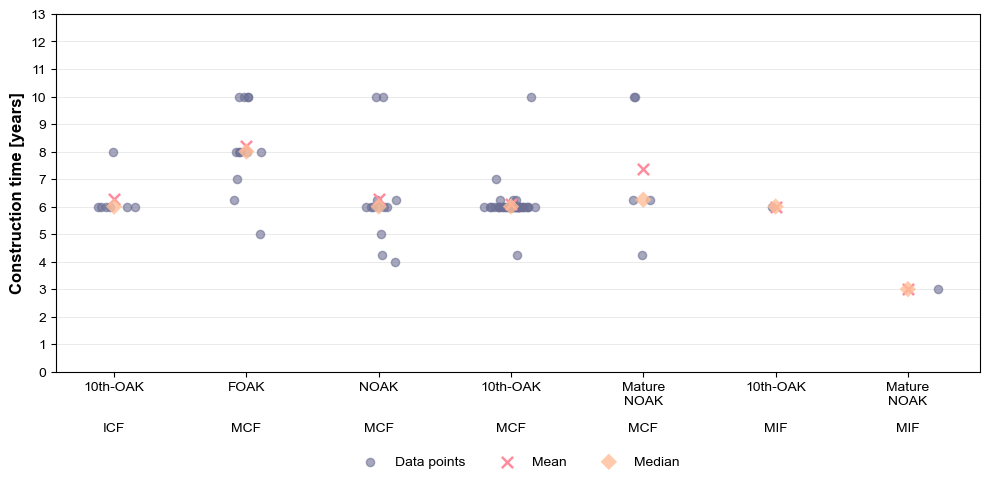

In [17]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# === Reset and style ===
plt.rcdefaults()
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams.update({
    "font.family": "Arial",
    "font.size": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "axes.labelweight": "normal",
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10
})

# === Construction time [years] grouped by maturity → confinement type ===
data = {
    # === Inertial Confinement Fusion (ICF) ===
    "10th-OAK\n\n\nICF": [
        # Conn et al. (1990): HYLIFE, CASCADE
        6, 6,
        # Waganer et al. (1992): Prometheus-L, Prometheus-H
        6, 6,
        # Maya et al. (1985): CASCADE – counted once
        6,
        # Blink et al. (1985): HYLIFE-I – distinct (8 yrs)
        8,
        # Moir (1992): HYLIFE-II – distinct (6 yrs)
        6
    ],

    # === Magnetic Confinement Fusion (MCF) ===
    "FOAK\n\n\nMCF": [
        # Lako & Seebregts (1998): 6.25 yrs
        6.25, 7,
        # Lerede et al. (2023): ARC, EU, Asian DEMO (5–10 yrs)
        5, 10, 10,
        # Spears (1990): Reactor-1, Reactor-2 etc.
        8, 8, 8, 8,
        # Entler (2018): DEMO2
        10,
        # Miller (1991)
        8,
     # Bednyagin (2011)
        10,
    ],

    "NOAK\n\n\nMCF": [
        # Lako & Seebregts (1998)
        6.25, 6.25,
        # Kikuchi et al. (1996): A-SSTR
        4,
        # Lerede (2023)
        5, 10,
        # Jo et al. (2021)
        6, 6, 6, 6,
        # Lindley et al. (2023): 4–5 yrs
        4.25,
        # Bednyagin (2011)
        10,
        # Dolan (2005)
        6, 6,
    ],
"10th-OAK\n\n\nMCF": [
    # Baker et al. (1980) – STARFIRE
    6,

    # Berwald et al. (1987) – MARS mirror
    6,
        # Bednyagin (2011)
        10,
    # Delene et al. (1988) – GENEROMAK / ESECOM variants (10 distinct)
    *[6]*10,

    # Conn et al. (1990) – ARIES I/II, TITAN, GENEROMAK LI/LI/V
    6, 6, 6, 6,

    # Delene (1991) – V-Li Tokamak + ARIES-I
    6, 6,

    # Delene (2001) – ARIES-RS/ST (min/base/max, both designs)
    6, 6,

    # Dolan (2005) – ARIES-SPSS
    6,

    # Drakojlovic (2010) – New ARIES
    6,

    # Lako & Seebregts (1998) – Commercial Twin Reactor
    6.25, 6.25,

    # Roulstone (2021)
    6.25,

    # Sheffield & Milora (2016) – ARIES RS, AT, AT-Adv, Model C, Generic Toroidal
    7, 6, 6, 6, 6,

    # Miller (1991)
    6,

    # Logan et al. (1990) – ESECOM / GENEROMAK variants
    *[6]*10,

    # Lindley et al. (2023) – Small modular tokamak
    4.25,
],
    "Mature\nNOAK\n\nMCF": [
       # Lako & Seebregts (1998)
        6.25, 6.25,
        # Lindley et al. (2023)
        4.25,
                # Bednyagin (2011)
        10, 10, 
    ],

    # === Magneto-Inertial Fusion (MIF) ===
    "10th-OAK\n\n\nMIF": [
        # Woodruff et al. (2017): count once (represents all four techs)
        6,
    ],

    "Mature\nNOAK\n\nMIF": [
        # Hsu et al. (2020) 
        3,
    ],
}

# === Figure ===
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(data))

# === Plot ===
for i, (label, vals) in enumerate(data.items()):
    vals = np.array(vals)
    if len(vals) == 0:
        continue

    x_jitter = np.random.normal(i, 0.08, size=len(vals))

    # Data points
    ax.scatter(
        x_jitter, vals,
        s=35, color="#6c6f93", alpha=0.6, zorder=3,
        label="Data points" if i == 0 else None
    )

    # Mean
    ax.scatter(
        i, np.mean(vals),
        color="#FF8C9E", marker="x", s=65,
        linewidths=1.8, zorder=5,
        label="Mean" if i == 0 else None
    )

    # Median
    ax.scatter(
        i, np.median(vals),
        color="#FFBE98", marker="D", s=70,
        alpha=0.8, edgecolors="none", zorder=6,
        label="Median" if i == 0 else None
    )

# === Axes formatting ===
ax.set_xticks(x_positions)
ax.set_xticklabels(list(data.keys()), rotation=0, ha="center", fontweight="normal")
ax.set_ylabel("Construction time [years]", fontweight="bold", fontsize=12)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("normal")

ax.set_ylim(0, 13)
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.3)
ax.yaxis.set_major_locator(plt.MultipleLocator(1))

# === Legend ===
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    frameon=False
)

plt.tight_layout()
plt.show()
fig.savefig("construction_time_maturity_updated.png", dpi=600, bbox_inches="tight")


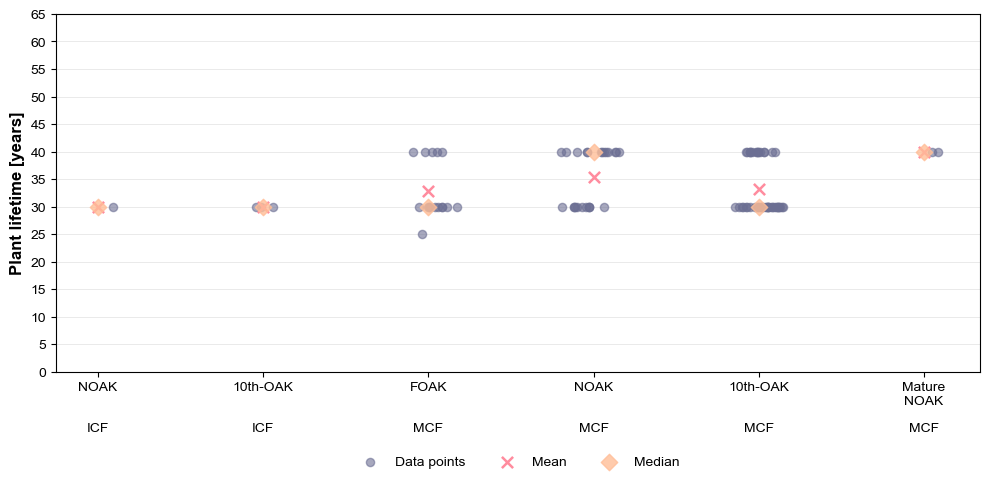

In [3]:
# === Data grouped by maturity → confinement type ===
# Only PLANT lifetimes (no blanket/FW/divertor FPY, no replacement intervals)

data = {

    # === ICF (Inertial) ===

    # NOAK ICF:
    # - IFE (FLIBE breeder, Yamazaki 2011) – 30y
    "NOAK\n\n\nICF": [
        30,  # IFE (Yamazaki 2011)
    ],

    # 10th-OAK ICF:
    # - HYLIFE-I (Blink 1985) – 30y
    # - CASCADE (Maya 1985) – 30y
    # - HYLIFE-II (Moir 1992) – 30y
    "10th-OAK\n\n\nICF": [
        30,          # HYLIFE-I (Blink 1985)
        30,          # CASCADE (Maya 1985) – single case
        30,          # HYLIFE-II (Moir 1992)
    ],

    # === MCF (Magnetic confinement) ===

    # FOAK MCF:
    # - DEMO2 (Entler 2018) – 40y
    # - ITER (IAEA 2001) – 20y
    # - SSTR-like DEMO (Oishi 2012) – 30y
    # - EU-DEMO FOAK (Lerede 2023) – 40y
    # - Asian-DEMO FOAK (Lerede 2023) – 40y
    # - ARC-2035 FOAK (Lerede 2023) – 40y
    # - Stellarator (Famà 2023, 8 options) – 30y each
    # - Spears (ESECOM, 1989) – 25y
    # Bednyagin & Gnansounou (2011) for all maturity
    "FOAK\n\n\nMCF": [
        40,  # DEMO2 (Entler 2018)
        30,  # SSTR-like DEMO (Oishi 2012)
        40,  # EU-DEMO (Lerede 2023)
        40,  # Asian-DEMO (Lerede 2023)
        40,  # ARC-2035 (Lerede 2023)
        *([30] * 8),  # Famà 2023 – 8 stellarator options (4x greenfield + 4x restructured)
        25,  # Spears (ESECOM 1989)
        40, #Bednyagin & Gnansounou (2011)
       30, # Miller
    ],

    # NOAK MCF:
    # - Bednyagin & Gnansounou 2011 (single NOAK case) – 40y
    # - Vaillancourt 2008 – 40y
    # - Yamazaki 2009 (Tokamak / ST / Helical) – 3x 30y
    # - Yamazaki 2011 (7 total variants: Hybrid, D–3He, DT Tokamak/ST/Helical) – 7x 30y
    # - Kozaki 2009 (LHD – 4x capacity variants) – 4x 40y
    # - Lako & Seebregts 1998 – 30y
    # - ARC-2050 (Lerede 2023) – 40y
    # - EU-DEMO Advanced (Lerede 2023) – 40y
    "NOAK\n\n\nMCF": [
        40,  # Bednyagin & Gnansounou 2011
        40,  # Vaillancourt 2008
        30, 30, 30,  # Yamazaki 2009 (Tokamak, ST, Helical)
        *([30] * 7),  # Yamazaki 2011 (7 reactors)
        *([40] * 4),  # Kozaki 2009 (LHD – 4 capacity variants)
        30,  # Lako & Seebregts 1998
        40, 40,  # ARC-2050 (Lerede 2023)
        40,  # EU-DEMO Advanced (Lerede 2023)
       40, 40, 40, 40, # Jo et al. (2021)

    ],

    # 10th-OAK MCF:
    # - Bednyagin 2011 (10th-OAK scenario) – 40y
    # - Delene 1988 (Generomak family, 10 variants) – 10x 30y
    # - Delene 1991 (V-Li/TOK x2) – 2x 30y
    # - Delene 2000 (ARIES-RS & ARIES-ST) – 2x 30y
    # - Tsoulfanidis 1981 (UWMAK-III) – 30y
    # - Miller 1991 (ARIES-code & SCAN-code reactors) – 2x 30y
    # Wittenberg 30 years
    # - STARFIRE (Baker 1980 & Sheffield 1986) – 2x 30y
    # - Sheffield & Milora 2016 (Model C & Generic Toroidal) – 40y, 30y
    # - Kessel et al. 2015 (ACT1 & ACT2) – 2x 40y
    # - Gi et al. 2020 (Conventional & Advanced R&D) – 2x 40y
    # - PPCS (Ward 2005) – 4x 40y
    # - ARIES (Krakowski 1995; I–IV) – 4x 40y
    # - ARIES-AT (Najmabadi 2006) – 40y
    # Logan et al. (1990)
   # Baker (1980)
    "10th-OAK\n\n\nMCF": [
        40,  # Bednyagin 2011 (10th-OAK)
        *([30] * 10),  # Delene 1988 (Generomak – 10 designs)
        30, 30,  # Delene 1991 (2 V-Li/TOK safety levels)
        30, 30,  # Delene 2000 (ARIES-RS, ARIES-ST)
        30,  # Tsoulfanidis 1981 (UWMAK-III)
        30, 30,  # Miller 1991 (ARIES-code & SCAN-code)
        30,   # STARFIRE (Sheffield)
        40, 30,  # Sheffield & Milora 2016 (Model C, Generic Toroidal)
        40, 40,  # Kessel et al. (ACT1, ACT2)
        40, 40,  # Gi et al. 2020 (Conventional, Advanced)
        40, 40, 40, 40,  # PPCS A–D (Najmbadadi)
        40, 40, 40, 40,  # ARIES I–IV (Krakowski)
        40,  # ARIES-AT (Najmabadi 2006)
        30, # Baker (1980)
                *[30]*10, # Logan et al. (1990)
      30, #  Wittenberg 
    ],

    # Mature NOAK MCF:
    # - Bednyagin & Gnansounou 2011 (advanced, highly advanced) – 2x 40y
    "Mature\nNOAK\n\nMCF": [
        40, 40,
    ],
}

# === Figure ===
fig, ax = plt.subplots(figsize=(10, 5))
x_positions = np.arange(len(data))

# === Plot ===
for i, (label, vals) in enumerate(data.items()):
    vals = np.array(vals, dtype=float)
    if len(vals) == 0:
        continue

    # Jitter for better visualization
    x_jitter = np.random.normal(i, 0.08, size=len(vals))

    # --- Data points ---
    ax.scatter(
        x_jitter, vals,
        s=35,
        color="#6c6f93",
        alpha=0.6,
        edgecolors="face",
        zorder=3,
        label="Data points" if i == 0 else "_nolegend_"
    )

    # --- Mean ---
    ax.scatter(
        i, np.mean(vals),
        color="#FF8C9E",
        marker="x",
        s=65,
        linewidths=1.8,
        zorder=5,
        label="Mean" if i == 0 else "_nolegend_"
    )

    # --- Median ---
    ax.scatter(
        i, np.median(vals),
        color="#FFBE98",
        marker="D",
        s=70,
        alpha=0.8,
        edgecolors="face",
        zorder=6,
        label="Median" if i == 0 else "_nolegend_"
    )

# === Axes formatting ===
ax.set_xticks(x_positions)
ax.set_xticklabels(
    list(data.keys()),
    rotation=0,
    ha="center",
    fontweight="normal",
)
ax.set_ylabel("Plant lifetime [years]", fontweight="bold", fontsize=12)

for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontweight("normal")

ax.set_ylim(0, 65)  # covers 20–60 y nicely
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle="-", linewidth=0.6, alpha=0.3)
ax.yaxis.set_major_locator(plt.MultipleLocator(5))

# === Legend ===
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.2),
    ncol=3,
    frameon=False
)

plt.tight_layout()

# === Save before showing (safer for some backends) ===
fig.savefig("plant_lifetime_maturity_first_final.png", dpi=600, bbox_inches="tight")
plt.show()


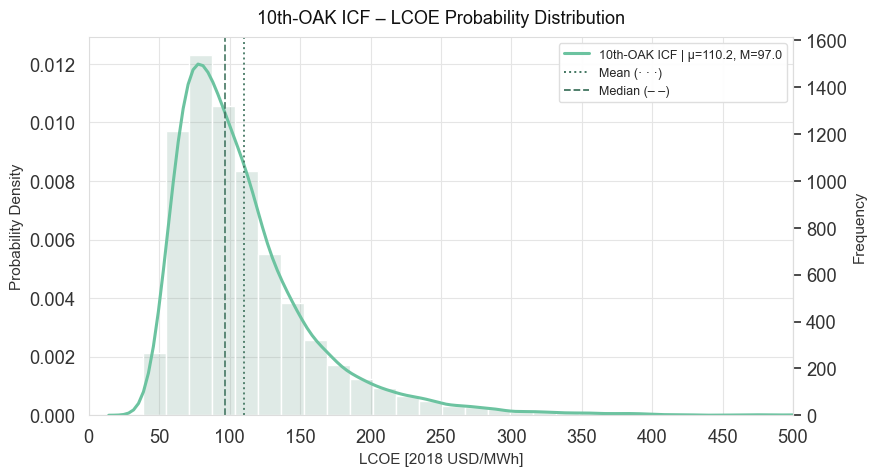

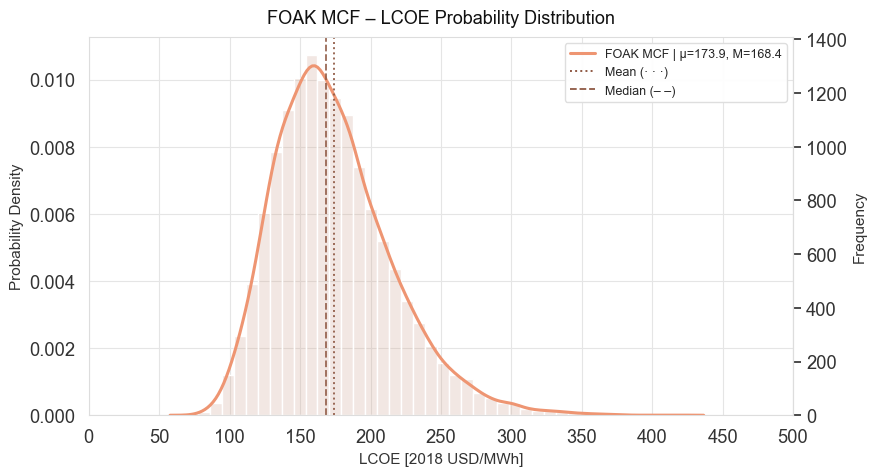

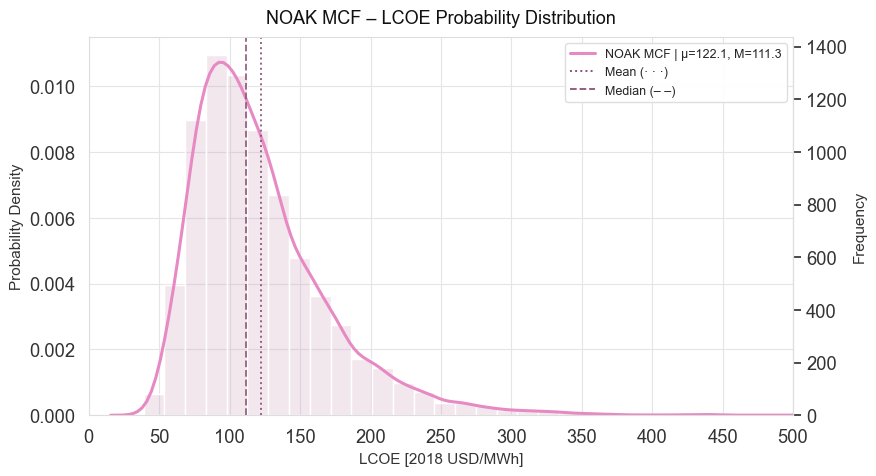

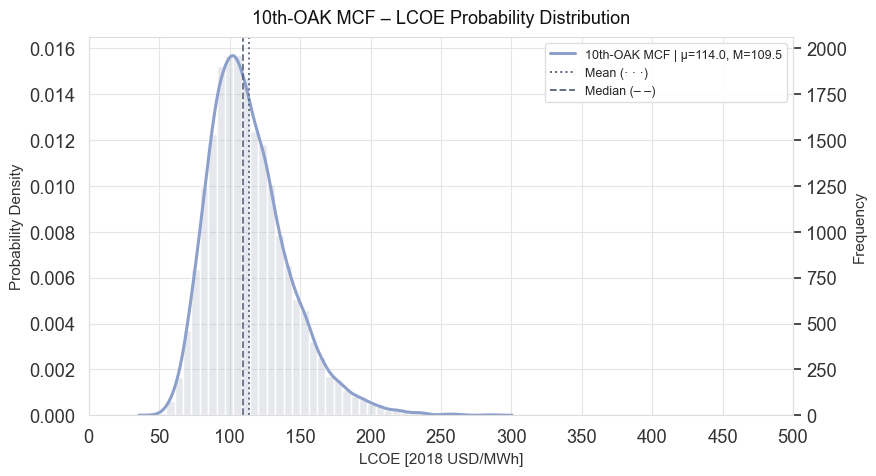

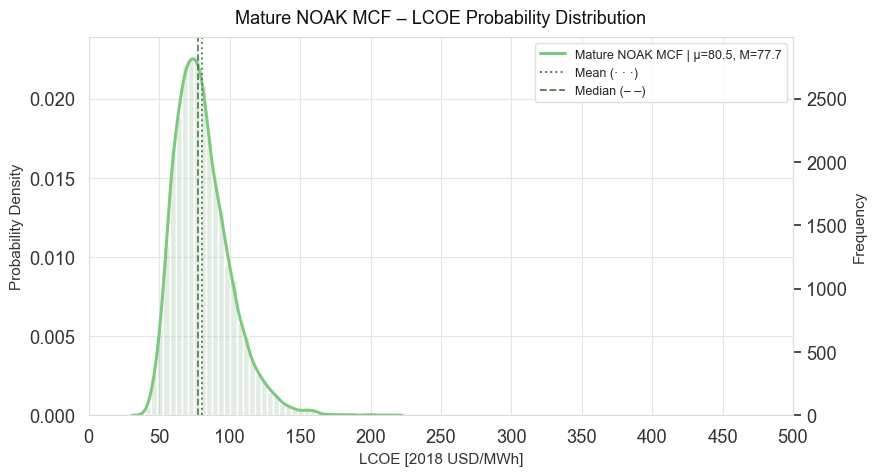

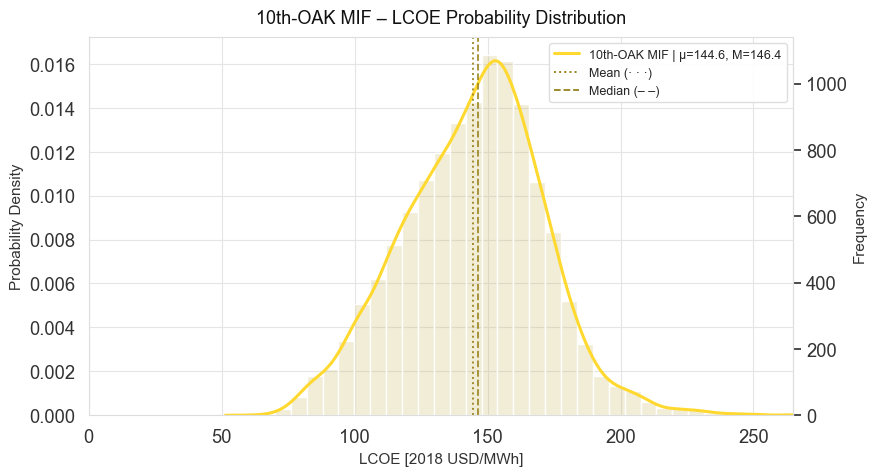

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb
from matplotlib.ticker import MultipleLocator

# ---------------------------------------------------------
# Simulation constants
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "axes.facecolor": "white",
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#DDDDDD",
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#111111"
})

r = 0.07
Capacity = 1000          # MW
N = 10000
hours_per_year = 8760

# ---------------------------------------------------------
# Reactor input parameters
# ---------------------------------------------------------
reactors = {
    "ICF_10th-OAK": {"mu_occ": 8.391098793, "sigma_occ": 0.633502713,
                     "mu_om": 4.905285179, "sigma_om": 0.119,
                     "OandM_var": 14.85840237, "life": 30, "Tcon": 6,
                     "Fuel": 1.113, "CF": 0.76},

    "MCF_FOAK": {"mu_occ": 9.195902399, "sigma_occ": 0.270504713,
                 "mu_om": 4.480605914, "sigma_om": 0.273075313,
                 "OandM_var": 9.99048508, "life": 30, "Tcon": 8,
                 "Fuel": 0.125, "CF": 0.75},
    
    "MCF_NOAK": {"mu_occ": 8.735452888, "sigma_occ": 0.506252252,
                 "mu_om": 4.58845646, "sigma_om": 0.30494928,
                 "OandM_var": 15.01183152, "life": 40, "Tcon": 6,
                 "Fuel": 0.0457, "CF": 0.75},

    "MCF_10th-OAK": {"mu_occ": 8.655215232, "sigma_occ": 0.330803161,
                     "OandM_fix_mean": 100.5938118, "OandM_fix_std": 28.67511156,
                     "OandM_var": 14.85840237, "life": 30, "Tcon": 6,
                     "Fuel": 0.115, "CF": 0.75},

    "MCF_Mature": {"mu_occ": 8.41820458, "sigma_occ": 0.327610948,
                   "OandM_fix_const": 95.2223, "OandM_var": 8.603549942,
                   "life": 40, "Tcon": 6.3, "Fuel": 0.115, "CF": 0.80},

    "MIF_10th-OAK": {"a_occ": 4889.47, "b_occ": 13426.86, "c_occ": 12391.07,
                     "mu_om": 5.206309997, "sigma_om": 0.528360371,
                     "OandM_var": 0.0, "life": 30, "Tcon": 6,
                     "Fuel": 0.0236, "CF": 0.9}
}

# ---------------------------------------------------------
# Helper functions
# ---------------------------------------------------------
def idc_calc(r, Tcon):
    """Interest during construction"""
    return (r * Tcon / 2) + (r ** 2 * Tcon / 6)

def lcoe_from_params(OCC, OandM_fix, OandM_var, lifetime, Tcon, CF, Fuel):
    """Unit-consistent LCOE in USD/MWh"""
    idc = idc_calc(r, Tcon)
    TCC = OCC * (1 + idc)  # USD/kW
    years = np.arange(0, lifetime + 1)
    disc = (1 + r) ** (-years)
    annual_om_fuel = (OandM_fix * 1000 * Capacity) + ((OandM_var + Fuel) * CF * hours_per_year * Capacity)
    num = np.sum((TCC * 1000 * Capacity * (years == 0) + annual_om_fuel) * disc)
    den = np.sum(hours_per_year * CF * Capacity * disc)
    return num / den  # USD/MWh

# ---------------------------------------------------------
# Monte Carlo simulation
# ---------------------------------------------------------
samples = {}
for key, vals in reactors.items():
    # OCC
    if "mu_occ" in vals:
        occ_samples = np.random.lognormal(vals["mu_occ"], vals["sigma_occ"], N)
    else:
        occ_samples = np.random.triangular(vals["a_occ"], vals["c_occ"], vals["b_occ"], N)
        occ_samples = occ_samples[occ_samples < 20000]

    # Fixed O&M
    if "OandM_fix_const" in vals:
        om_fix_samples = np.full(N, vals["OandM_fix_const"])
    elif "OandM_fix_mean" in vals:
        om_fix_samples = np.random.normal(vals["OandM_fix_mean"], vals["OandM_fix_std"], N)
    else:
        om_fix_samples = np.random.lognormal(vals["mu_om"], vals["sigma_om"], N)

    om_var = vals["OandM_var"]

    # Compute LCOE for each sample
    lcoe_values = np.array([
        lcoe_from_params(o, f, om_var, vals["life"], vals["Tcon"], vals["CF"], vals["Fuel"])
        for o, f in zip(occ_samples, om_fix_samples)
    ])
    samples[key] = lcoe_values[np.isfinite(lcoe_values) & (lcoe_values < 10000)]  # filter outliers

# ---------------------------------------------------------
# Rename samples for readable labels
# ---------------------------------------------------------
samples_original = samples.copy()
samples = {
    "10th-OAK ICF": samples_original["ICF_10th-OAK"],
    "FOAK MCF": samples_original["MCF_FOAK"],
    "NOAK MCF": samples_original["MCF_NOAK"],
    "10th-OAK MCF": samples_original["MCF_10th-OAK"],
    "Mature NOAK MCF": samples_original["MCF_Mature"],
    "10th-OAK MIF": samples_original["MIF_10th-OAK"]
}

# ---------------------------------------------------------
# Visual style
# ---------------------------------------------------------
sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "axes.facecolor": "white",
    "grid.color": "#E5E5E5",
    "grid.linewidth": 0.8,
    "axes.edgecolor": "#DDDDDD",
    "axes.linewidth": 0.8,
    "figure.facecolor": "white",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#111111"
})

# ---------------------------------------------------------
# Helper function
# ---------------------------------------------------------
def darken(color, factor=0.7):
    r, g, b = to_rgb(color)
    return (r * factor, g * factor, b * factor)

# ---------------------------------------------------------
# Colors per reactor type
# ---------------------------------------------------------
pdf_colors = {
    "10th-OAK ICF": "#6CC3A0",     # teal
    "FOAK MCF": "#EE9572",        # orange
    "NOAK MCF": "#E78AC3",        # pink
    "10th-OAK MCF": "#8DA0CB",    # blue
    "Mature NOAK MCF": "#7FC97F", # green
    "10th-OAK MIF": "#FFD92F"     # yellow
}

# ---------------------------------------------------------
# Plot each reactor separately
# ---------------------------------------------------------
for reactor_key, data in samples.items():
    fig, ax = plt.subplots(figsize=(9, 5))
    mean_val = np.mean(data)
    median_val = np.median(data)

    base_color = pdf_colors[reactor_key]
    line_color = darken(base_color, 0.6)
    light_color = sns.desaturate(base_color, 0.5)

    # Histogram
    sns.histplot(data, bins=40, stat="density",
                 color=light_color, alpha=0.25, edgecolor=None, ax=ax)

    # KDE line
    sns.kdeplot(data, color=base_color, lw=2.2, ax=ax)

    # Mean (dotted) and Median (dashed)
    ax.axvline(mean_val, color=line_color, ls=":", lw=1.4, alpha=0.9)
    ax.axvline(median_val, color=line_color, ls="--", lw=1.3, alpha=0.9)

    # Labels
    ax.set_xlabel("LCOE [2018 USD/MWh]", fontsize=11)
    ax.set_ylabel("Probability Density", fontsize=11)
    ax.set_title(f"{reactor_key} – LCOE Probability Distribution", fontsize=13, pad=10)

    # Gridlines
    ax.xaxis.set_major_locator(MultipleLocator(50))   # x-axis ticks every 50 USD
    ax.grid(which="major", axis="both", linestyle="-", linewidth=0.8, color="#E5E5E5")
    ax.grid(which="minor", axis="both", linestyle="--", linewidth=0.5, color="#F0F0F0", alpha=0.5)

    # X-axis limits
    if reactor_key.startswith("10th-OAK MIF"):
        xmax = np.percentile(data, 99.5)
        ax.set_xlim(0, xmax * 1.2)
    else:
        ax.set_xlim(0, 500)

    # Right-side frequency axis
    n_samples = len(data)
    xlim = ax.get_xlim()
    bins = 40
    bin_width = (xlim[1] - xlim[0]) / bins
    def density_to_count(y): return y * n_samples * bin_width
    def count_to_density(y): return y / (n_samples * bin_width)
    ax_freq = ax.secondary_yaxis('right', functions=(density_to_count, count_to_density))
    ax_freq.set_ylabel("Frequency", fontsize=11)

    # Legend
    legend_elements = [
        Line2D([0, 1], [0, 0], color=base_color, lw=2.2,
               label=f"{reactor_key} | μ={mean_val:.1f}, M={median_val:.1f}"),
        Line2D([0, 1], [0, 0], color=line_color, ls=":", lw=1.4, label="Mean (· · ·)"),
        Line2D([0, 1], [0, 0], color=line_color, ls="--", lw=1.3, label="Median (– –)")
    ]
    ax.legend(handles=legend_elements, loc="upper right", fontsize=9,
              frameon=True, facecolor="white", edgecolor="#DDDDDD", framealpha=0.95)

    # Save & show
    plt.tight_layout()
    plt.savefig(f"{reactor_key.replace(' ', '_')}_PDF_with_Frequency_updated.png",
                dpi=400, bbox_inches="tight")
    plt.show()


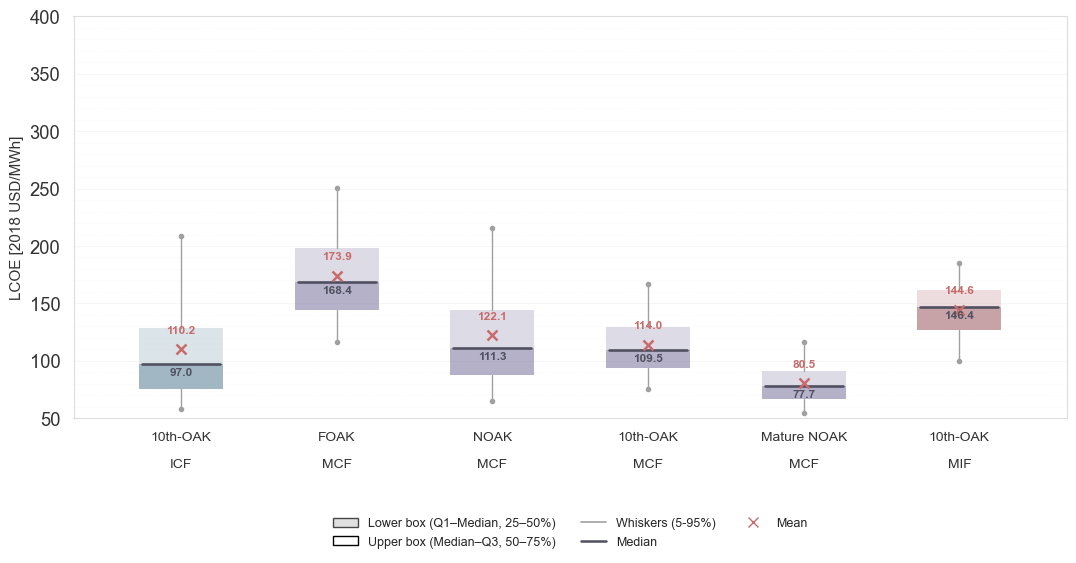

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# =========================================================
# Build DataFrame FROM Monte Carlo samples
# =========================================================
df_box = pd.DataFrame(
    [(k, v) for k, arr in samples.items() for v in arr],
    columns=["Reactor", "LCOE [USD/MWh]"]
)

# =========================================================
# Order & labels
# =========================================================
reactor_order = [
    "10th-OAK ICF",
    "FOAK MCF",
    "NOAK MCF",
    "10th-OAK MCF",
    "Mature NOAK MCF",
    "10th-OAK MIF"
]

labels = [
    "10th-OAK\n\nICF",
    "FOAK\n\nMCF",
    "NOAK\n\nMCF",
    "10th-OAK\n\nMCF",
    "Mature NOAK\n\nMCF",
    "10th-OAK\n\nMIF"
]

families = {
    "10th-OAK ICF": "ICF",
    "FOAK MCF": "MCF",
    "NOAK MCF": "MCF",
    "10th-OAK MCF": "MCF",
    "Mature NOAK MCF": "MCF",
    "10th-OAK MIF": "MIF"
}

# =========================================================
# Colour palette
# =========================================================
family_colors = {
    "ICF_lower": "#7A99AC",
    "ICF_upper": "#BFCED6",
    "MCF_lower": "#9590B2",
    "MCF_upper": "#C2BFD3",
    "MIF_lower": "#B07C83",
    "MIF_upper": "#DFC2C3"
}

median_color = "#505060"
mean_color   = "#c96a6a"

# =========================================================
# Figure setup
# =========================================================
plt.figure(figsize=(11, 6))
ax = sns.boxplot(
    data=df_box,
    x="Reactor",
    y="LCOE [USD/MWh]",
    order=reactor_order,
    showcaps=False,
    showfliers=False,
    boxprops=dict(facecolor="none", edgecolor="none"),
    medianprops=dict(color="none"),
    whiskerprops=dict(color="none"),
    zorder=1
)

# =========================================================
# Custom boxes, whiskers, statistics
# =========================================================
for i, reactor in enumerate(reactor_order):

    data = df_box.loc[df_box["Reactor"] == reactor, "LCOE [USD/MWh]"].values
    q1, q2, q3 = np.percentile(data, [25, 50, 75])
    wlow, whigh = np.percentile(data, [5, 95])
    mean_val = np.mean(data)

    fam = families[reactor]

    # --- Lower IQR (Q1–Median)
    ax.add_patch(Rectangle(
        (i - 0.27, q1), 0.54, q2 - q1,
        facecolor=family_colors[f"{fam}_lower"], alpha=0.70, lw=0
    ))

    # --- Upper IQR (Median–Q3)
    ax.add_patch(Rectangle(
        (i - 0.27, q2), 0.54, q3 - q2,
        facecolor=family_colors[f"{fam}_upper"], alpha=0.55, lw=0
    ))

    # --- Whiskers (5–95 %)
    ax.plot([i, i], [q3, whigh], color="#A0A0A0", lw=1.0, zorder=3)
    ax.plot([i, i], [q1, wlow],  color="#A0A0A0", lw=1.0, zorder=3)
    ax.plot(i, wlow,  "o", color="#A0A0A0", ms=3, zorder=4)
    ax.plot(i, whigh, "o", color="#A0A0A0", ms=3, zorder=4)

    # --- Median line (unchanged)
    ax.plot([i - 0.25, i + 0.25], [q2, q2],
            color=median_color, lw=1.9, zorder=5)

    # --- Mean marker (unchanged)
    ax.plot(i, mean_val, "x",
            color=mean_color, ms=6.5, mew=1.8, zorder=6)

    # --- Numeric labels (ONLY text bold)
    ax.text(
        i, q2 - 10,
        f"{q2:.1f}",
        color=median_color,
        ha="center",
        fontsize=8.5,
        fontweight="bold",
        zorder=7
    )

    ax.text(
        i, mean_val + 14,   # raised to avoid overlap
        f"{mean_val:.1f}",
        color=mean_color,
        ha="center",
        fontsize=8.5,
        fontweight="bold",
        zorder=7
    )

# =========================================================
# Axes & grid
# =========================================================
ax.set_ylabel("LCOE [2018 USD/MWh]", fontsize=11)
ax.set_xlabel("")
ax.set_ylim(50, 400)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=10)

ax.yaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_minor_locator(MultipleLocator(10))
ax.grid(which="major", axis="y", linewidth=0.6, alpha=0.4)
ax.grid(which="minor", axis="y", linestyle="--", linewidth=0.4, alpha=0.25)

# =========================================================
# Legend
# =========================================================
legend_elements = [
    Rectangle(
        (0, 0), 1, 1,
        facecolor="lightgray",
        edgecolor="black",
        alpha=0.7,
        label="Lower box (Q1–Median, 25–50%)"
    ),
    Rectangle(
        (0, 0), 1, 1,
        facecolor="white",
        edgecolor="black",
        alpha=1.0,
        label="Upper box (Median–Q3, 50–75%)"
    ),
    Line2D(
        [0, 1], [0, 0],
        color="#A0A0A0",
        lw=1.2,
        label="Whiskers (5-95%)"
    ),
    Line2D(
        [0, 1], [0, 0],
        color="#505060",
        lw=1.8,
        label="Median"
    ),
    Line2D(
        [0], [0],
        marker="x",
        color="#c96a6a",
        markersize=7,
        lw=0,
        label="Mean"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.22),
    ncol=3,
    frameon=False,
    fontsize=9
)


# =========================================================
# Save & show
# =========================================================
plt.tight_layout()
plt.savefig("LCOE_Boxplot_from_MonteCarlo_updated.png", dpi=400, bbox_inches="tight")
plt.show()


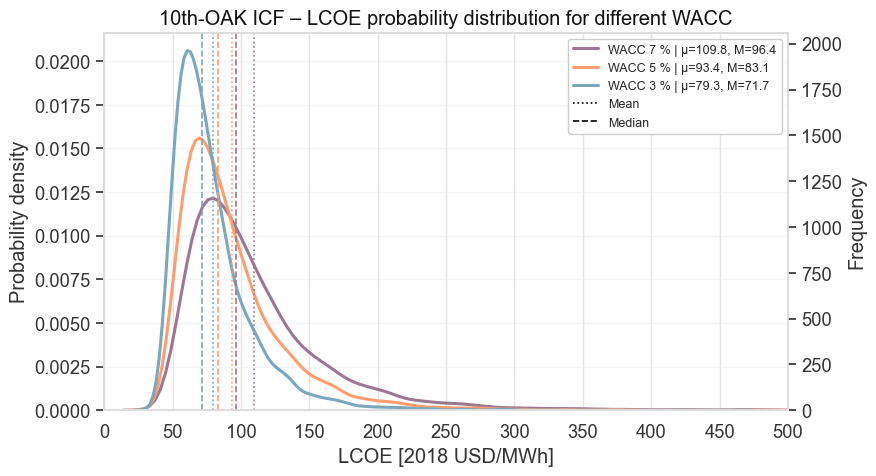

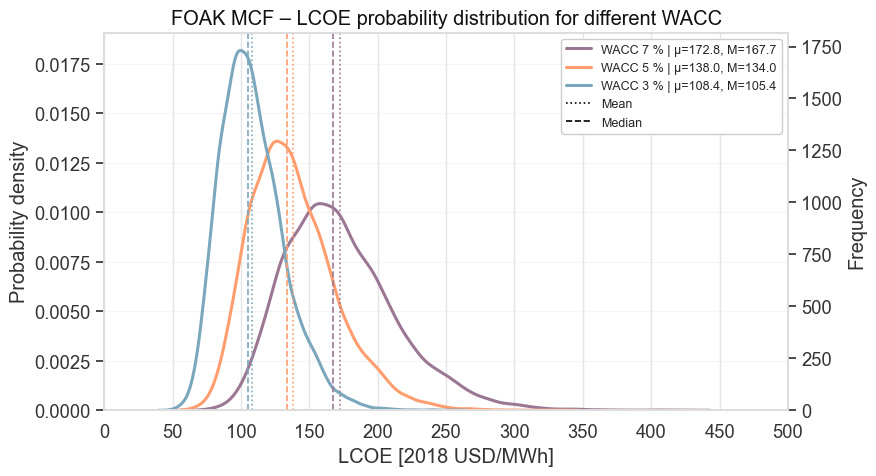

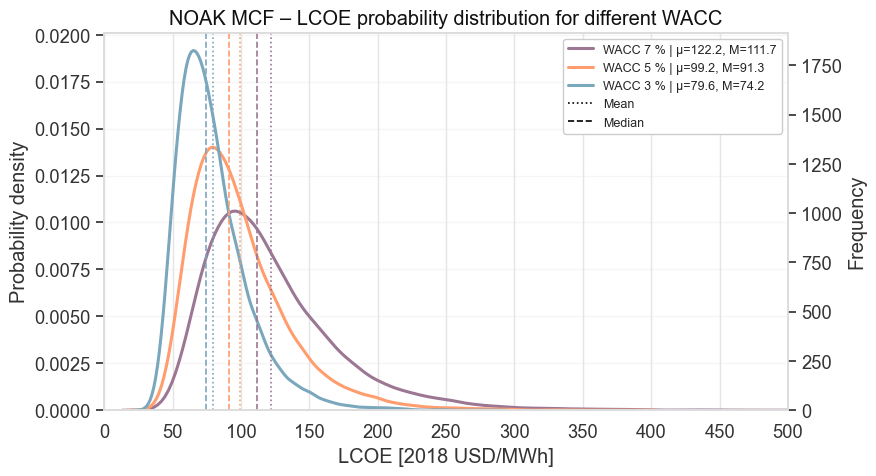

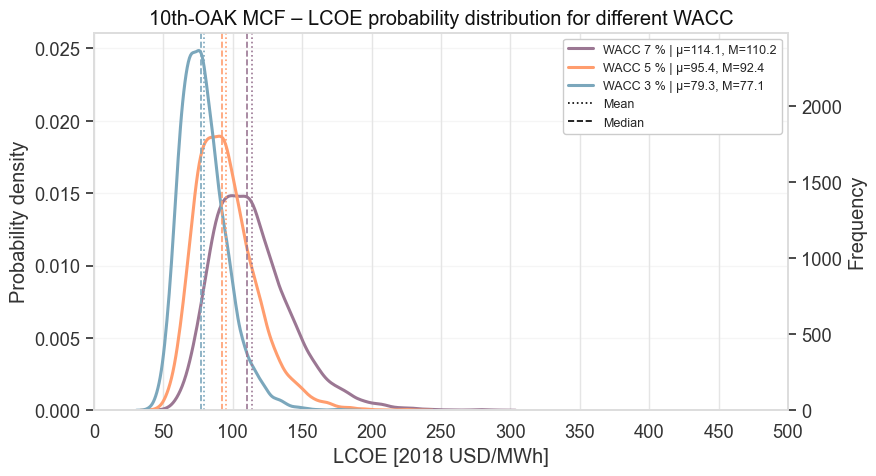

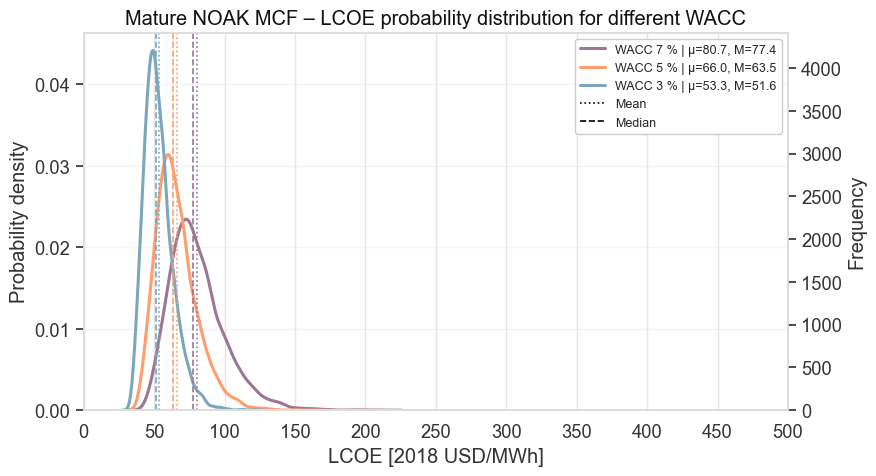

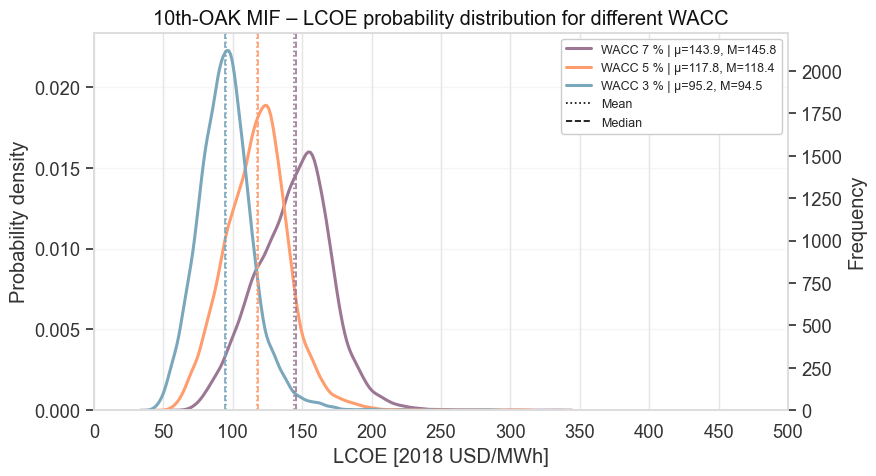

In [35]:
# =========================================================
# Monte Carlo LCOE simulation with WACC sensitivity
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# ---------------------------------------------------------
# Global settings
# ---------------------------------------------------------
np.random.seed(42)

sns.set_theme(style="whitegrid", font_scale=1.2)
plt.rcParams.update({
    "axes.facecolor": "white",
    "grid.color": "#E5E5E5",
    "axes.edgecolor": "#DDDDDD",
    "figure.facecolor": "white",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#111111"
})

# ---------------------------------------------------------
# Constants
# ---------------------------------------------------------
N = 10_000
Capacity = 1000        # MW
hours_per_year = 8760
discount_rates = [0.07, 0.05, 0.03]

# ---------------------------------------------------------
# Reactor input parameters
# ---------------------------------------------------------
reactors = {
    "ICF_10th-OAK": {"mu_occ": 8.391098793, "sigma_occ": 0.633502713,
                     "mu_om": 4.905285179, "sigma_om": 0.119,
                     "OandM_var": 14.85840237, "life": 30, "Tcon": 6,
                     "Fuel": 1.113, "CF": 0.76},

    "MCF_FOAK": {"mu_occ": 9.195902399, "sigma_occ": 0.270504713,
                 "mu_om": 4.480605914, "sigma_om": 0.273075313,
                 "OandM_var": 9.99048508, "life": 30, "Tcon": 8,
                 "Fuel": 0.125, "CF": 0.75},
    
    "MCF_NOAK": {"mu_occ": 8.735452888, "sigma_occ": 0.506252252,
                 "mu_om": 4.58845646, "sigma_om": 0.30494928,
                 "OandM_var": 15.01183152, "life": 40, "Tcon": 6,
                 "Fuel": 0.0457, "CF": 0.75},

    "MCF_10th-OAK": {"mu_occ": 8.655215232, "sigma_occ": 0.330803161,
                     "OandM_fix_mean": 100.5938118, "OandM_fix_std": 28.67511156,
                     "OandM_var": 14.85840237, "life": 30, "Tcon": 6,
                     "Fuel": 0.115, "CF": 0.75},

    "MCF_Mature": {"mu_occ": 8.41820458, "sigma_occ": 0.327610948,
                   "OandM_fix_const": 95.2223, "OandM_var": 8.603549942,
                   "life": 40, "Tcon": 6.3, "Fuel": 0.115, "CF": 0.80},

    "MIF_10th-OAK": {"a_occ": 4889.47, "b_occ": 13426.86, "c_occ": 12391.07,
                     "mu_om": 5.206309997, "sigma_om": 0.528360371,
                     "OandM_var": 0.0, "life": 30, "Tcon": 6,
                     "Fuel": 0.0236, "CF": 0.9}
}

# ---------------------------------------------------------
# Clean labels (maturity first, no underscores)
# ---------------------------------------------------------
reactor_labels = {
    "ICF_10th-OAK": "10th-OAK ICF",
    "MCF_FOAK": "FOAK MCF",
    "MCF_NOAK": "NOAK MCF",
    "MCF_10th-OAK": "10th-OAK MCF",
    "MCF_Mature": "Mature NOAK MCF",
    "MIF_10th-OAK": "10th-OAK MIF",
}

# ---------------------------------------------------------
# Financial functions
# ---------------------------------------------------------
def idc_calc(r, Tcon):
    return (r * Tcon / 2) + (r**2 * Tcon / 6)

def lcoe_from_params(OCC, OandM_fix, OandM_var, life, Tcon, CF, Fuel, r):
    idc = idc_calc(r, Tcon)
    TCC = OCC * (1 + idc)  # USD/kW
    years = np.arange(0, life + 1)
    disc = (1 + r) ** (-years)

    annual_costs = (
        OandM_fix * 1000 * Capacity +
        (OandM_var + Fuel) * CF * hours_per_year * Capacity
    )

    numerator = np.sum((TCC * 1000 * Capacity * (years == 0) + annual_costs) * disc)
    denominator = np.sum(hours_per_year * CF * Capacity * disc)

    return numerator / denominator  # USD/MWh

# ---------------------------------------------------------
# STEP 1 — Draw uncertainty ONCE (OCC + fixed O&M)
# ---------------------------------------------------------
occ_samples = {}
om_fix_samples = {}

for key, v in reactors.items():

    # OCC
    if "mu_occ" in v:
        occ = np.random.lognormal(v["mu_occ"], v["sigma_occ"], N)
    else:
        occ = np.random.triangular(v["a_occ"], v["c_occ"], v["b_occ"], N)

    # Fixed O&M
    if "OandM_fix_const" in v:
        om_fix = np.full(len(occ), v["OandM_fix_const"])
    elif "OandM_fix_mean" in v:
        om_fix = np.random.normal(v["OandM_fix_mean"], v["OandM_fix_std"], len(occ))
    else:
        om_fix = np.random.lognormal(v["mu_om"], v["sigma_om"], len(occ))

    occ_samples[key] = occ
    om_fix_samples[key] = om_fix

# ---------------------------------------------------------
# STEP 2 — Recompute LCOE for each WACC (no resampling!)
# ---------------------------------------------------------
results = {r: {} for r in discount_rates}

for r in discount_rates:
    for key, v in reactors.items():
        lcoe = np.array([
            lcoe_from_params(o, f, v["OandM_var"],
                             v["life"], v["Tcon"],
                             v["CF"], v["Fuel"], r)
            for o, f in zip(occ_samples[key], om_fix_samples[key])
        ])
        results[r][key] = lcoe[np.isfinite(lcoe)]

# ---------------------------------------------------------
# Colors for WACC
# ---------------------------------------------------------
wacc_colors = {0.07: "#9B7793", 0.05: "#FF9D6E", 0.03: "#7BA7BC"}

# ---------------------------------------------------------
# STEP 3 — Plot KDEs with secondary frequency axis
# ---------------------------------------------------------
bin_width = 10.0     # USD/MWh, used only to scale frequency axis
N_mc = N             # number of Monte Carlo samples

for key in reactors:
    label = reactor_labels[key]

    fig, ax = plt.subplots(figsize=(9, 5))

    # Secondary axis for frequency (numbers only)
    ax_freq = ax.twinx()

    max_density = 0.0

    # --- KDE curves + mean / median
    for r in discount_rates:
        data = results[r][key]

        mean = np.mean(data)
        median = np.median(data)

        kde = sns.kdeplot(
            data,
            ax=ax,
            color=wacc_colors[r],
            lw=2.2,
            clip=(0, None)
        )

        # Track max density for scaling the frequency axis
        yvals = kde.get_lines()[-1].get_ydata()
        max_density = max(max_density, yvals.max())

        # Mean / median lines
        ax.axvline(mean,   color=wacc_colors[r], ls=":",  lw=1.2, zorder=3)
        ax.axvline(median, color=wacc_colors[r], ls="--", lw=1.2, zorder=3)

    # -----------------------------------------------------
    # Axis formatting
    # -----------------------------------------------------
    ax.set_xlabel("LCOE [2018 USD/MWh]")
    ax.set_ylabel("Probability density")

    ax.set_xlim(0, 500)
    ax.xaxis.set_major_locator(MultipleLocator(50))

    # Left axis grid only
    ax.grid(True, axis="y", alpha=0.35)
    ax_freq.grid(False)

    # Right axis: frequency scale ONLY (no lines)
    ax_freq.set_ylabel("Frequency")
    ax_freq.set_ylim(0, max_density * N_mc * bin_width)

    # -----------------------------------------------------
    # Title
    # -----------------------------------------------------
    ax.set_title(f"{label} – LCOE probability distribution for different WACC")

    # -----------------------------------------------------
    # Legend (opaque, in front, no lines crossing)
    # -----------------------------------------------------
    legend_elements = []

    for r in discount_rates:
        mean = np.mean(results[r][key])
        median = np.median(results[r][key])

        legend_elements.append(
            Line2D(
                [0], [0],
                color=wacc_colors[r],
                lw=2.2,
                label=f"WACC {int(r*100)} % | μ={mean:.1f}, M={median:.1f}"
            )
        )

    legend_elements += [
        Line2D([0], [0], color="black", lw=1.2, ls=":",  label="Mean"),
        Line2D([0], [0], color="black", lw=1.2, ls="--", label="Median"),
    ]

    ax.legend(
        handles=legend_elements,
        loc="upper right",
        frameon=True,
        facecolor="white",
        edgecolor="#CCCCCC",
        framealpha=1.0,
        fontsize=9
    )

    plt.tight_layout()
    plt.savefig(f"{label.replace(' ', '_')}_LCOE_WACC_PDF_updated.png", dpi=400)
    plt.show()


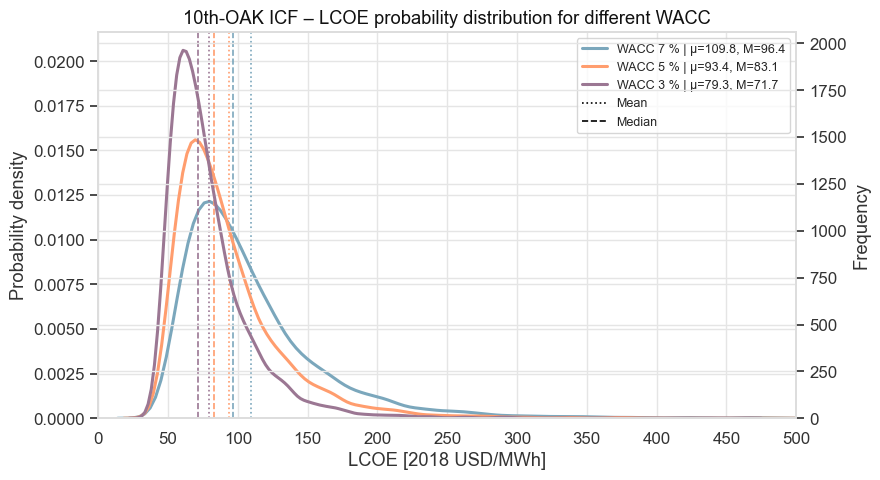

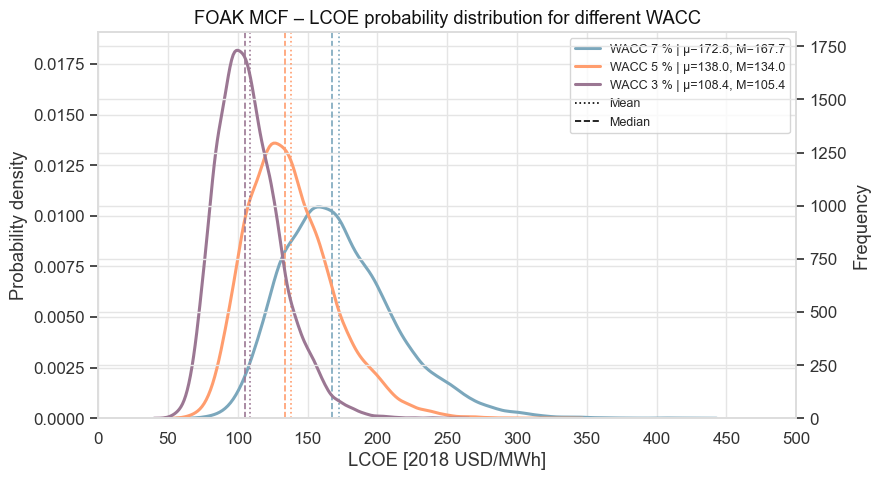

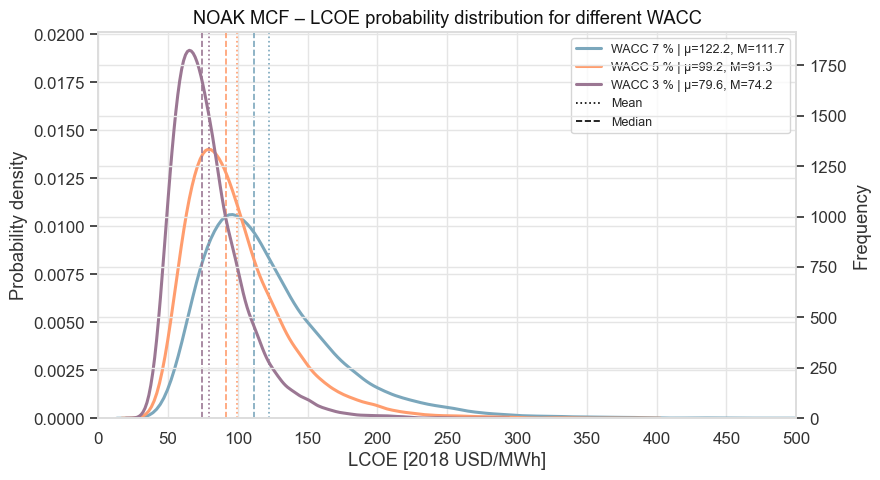

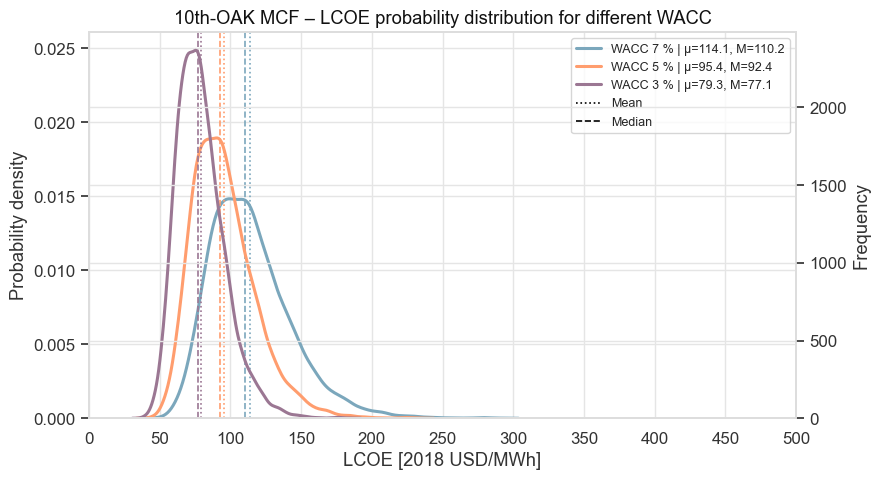

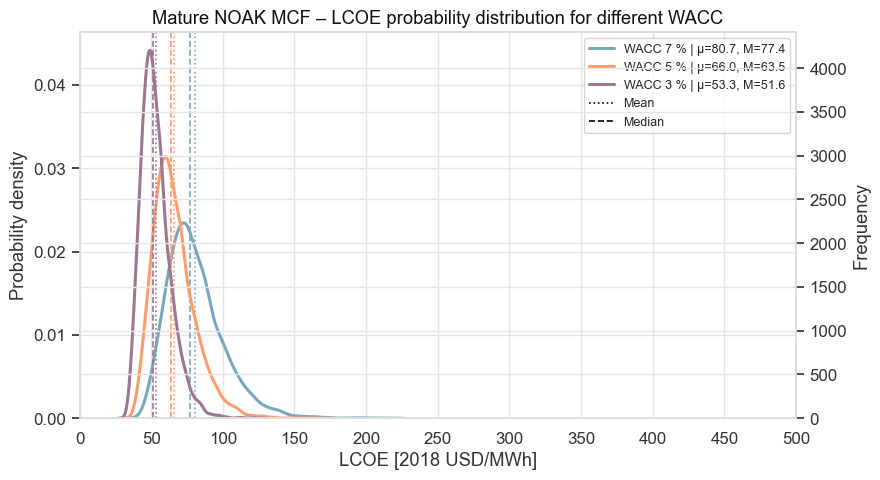

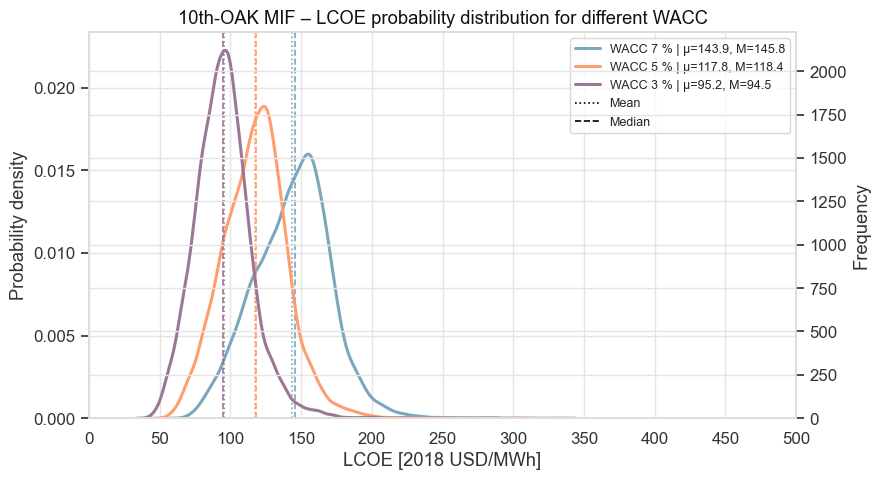

In [25]:
# =========================================================
# Monte Carlo LCOE simulation with WACC sensitivity
# KDE + frequency axis (no histogram bars)
# =========================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator

# ---------------------------------------------------------
# Global settings
# ---------------------------------------------------------
np.random.seed(42)

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "axes.facecolor": "white",
    "grid.color": "#E5E5E5",
    "axes.edgecolor": "#DDDDDD",
    "figure.facecolor": "white",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.labelcolor": "#333333",
    "axes.titlecolor": "#111111"
})

# ---------------------------------------------------------
# Constants
# ---------------------------------------------------------
N = 10_000
Capacity = 1000        # MW
hours_per_year = 8760
discount_rates = [0.07, 0.05, 0.03]

# ---------------------------------------------------------
# Reactor input parameters
# ---------------------------------------------------------
reactors = {
    "ICF_10th-OAK": {"mu_occ": 8.391098793, "sigma_occ": 0.633502713,
                     "mu_om": 4.905285179, "sigma_om": 0.119,
                     "OandM_var": 14.85840237, "life": 30, "Tcon": 6,
                     "Fuel": 1.113, "CF": 0.76},

    "MCF_FOAK": {"mu_occ": 9.195902399, "sigma_occ": 0.270504713,
                 "mu_om": 4.480605914, "sigma_om": 0.273075313,
                 "OandM_var": 9.99048508, "life": 30, "Tcon": 8,
                 "Fuel": 0.125, "CF": 0.75},
    
    "MCF_NOAK": {"mu_occ": 8.735452888, "sigma_occ": 0.506252252,
                 "mu_om": 4.58845646, "sigma_om": 0.30494928,
                 "OandM_var": 15.01183152, "life": 40, "Tcon": 6,
                 "Fuel": 0.0457, "CF": 0.75},

    "MCF_10th-OAK": {"mu_occ": 8.655215232, "sigma_occ": 0.330803161,
                     "OandM_fix_mean": 100.5938118, "OandM_fix_std": 28.67511156,
                     "OandM_var": 14.85840237, "life": 30, "Tcon": 6,
                     "Fuel": 0.115, "CF": 0.75},

    "MCF_Mature": {"mu_occ": 8.41820458, "sigma_occ": 0.327610948,
                   "OandM_fix_const": 95.2223, "OandM_var": 8.603549942,
                   "life": 40, "Tcon": 6.3, "Fuel": 0.115, "CF": 0.80},

    "MIF_10th-OAK": {"a_occ": 4889.47, "b_occ": 13426.86, "c_occ": 12391.07,
                     "mu_om": 5.206309997, "sigma_om": 0.528360371,
                     "OandM_var": 0.0, "life": 30, "Tcon": 6,
                     "Fuel": 0.0236, "CF": 0.9},
}

reactor_labels = {
    "ICF_10th-OAK": "10th-OAK ICF",
    "MCF_FOAK": "FOAK MCF",
    "MCF_NOAK": "NOAK MCF",
    "MCF_10th-OAK": "10th-OAK MCF",
    "MCF_Mature": "Mature NOAK MCF",
    "MIF_10th-OAK": "10th-OAK MIF",
}

# ---------------------------------------------------------
# Financial functions
# ---------------------------------------------------------
def idc_calc(r, Tcon):
    return (r * Tcon / 2) + (r**2 * Tcon / 6)

def lcoe_from_params(OCC, OandM_fix, OandM_var, life, Tcon, CF, Fuel, r):
    idc = idc_calc(r, Tcon)
    TCC = OCC * (1 + idc)  # USD/kW
    years = np.arange(0, life + 1)
    disc = (1 + r) ** (-years)

    annual_costs = (
        OandM_fix * 1000 * Capacity +
        (OandM_var + Fuel) * CF * hours_per_year * Capacity
    )

    numerator = np.sum((TCC * 1000 * Capacity * (years == 0) + annual_costs) * disc)
    denominator = np.sum(hours_per_year * CF * Capacity * disc)

    return numerator / denominator  # USD/MWh

# ---------------------------------------------------------
# Draw uncertainty ONCE
# ---------------------------------------------------------
occ_samples = {}
om_fix_samples = {}

for key, v in reactors.items():

    if "mu_occ" in v:
        occ = np.random.lognormal(v["mu_occ"], v["sigma_occ"], N)
    else:
        occ = np.random.triangular(v["a_occ"], v["c_occ"], v["b_occ"], N)

    if "OandM_fix_const" in v:
        om_fix = np.full(len(occ), v["OandM_fix_const"])
    elif "OandM_fix_mean" in v:
        om_fix = np.random.normal(v["OandM_fix_mean"], v["OandM_fix_std"], len(occ))
    else:
        om_fix = np.random.lognormal(v["mu_om"], v["sigma_om"], len(occ))

    occ_samples[key] = occ
    om_fix_samples[key] = om_fix

# ---------------------------------------------------------
# Recompute LCOE for each WACC
# ---------------------------------------------------------
results = {r: {} for r in discount_rates}

for r in discount_rates:
    for key, v in reactors.items():
        lcoe = np.array([
            lcoe_from_params(o, f, v["OandM_var"],
                             v["life"], v["Tcon"],
                             v["CF"], v["Fuel"], r)
            for o, f in zip(occ_samples[key], om_fix_samples[key])
        ])
        results[r][key] = lcoe[np.isfinite(lcoe)]

# ---------------------------------------------------------
# Plot KDE with frequency axis
# ---------------------------------------------------------
wacc_colors = {0.07: "#7BA7BC", 0.05: "#FF9D6E", 0.03: "#9B7793"}
bin_width = 10  # USD/MWh (for frequency scaling)

for key in reactors:
    label = reactor_labels[key]
    fig, ax = plt.subplots(figsize=(9, 5))
    ax_freq = ax.twinx()

    max_density = 0

    for r in discount_rates:
        data = results[r][key]
        mean = np.mean(data)
        median = np.median(data)

        kde = sns.kdeplot(
            data,
            lw=2.2,
            color=wacc_colors[r],
            ax=ax
        )

        y_vals = kde.get_lines()[-1].get_ydata()
        max_density = max(max_density, y_vals.max())

        ax.axvline(mean,   color=wacc_colors[r], ls=":",  lw=1.2)
        ax.axvline(median, color=wacc_colors[r], ls="--", lw=1.2)

    ax.set_xlabel("LCOE [2018 USD/MWh]")
    ax.set_ylabel("Probability density")
    ax_freq.set_ylabel("Frequency")

    ax_freq.set_ylim(0, max_density * N * bin_width)

    ax.set_xlim(0, 500)
    ax.xaxis.set_major_locator(MultipleLocator(50))

    legend_elements = [
        Line2D([0], [0], color=wacc_colors[r], lw=2.2,
               label=f"WACC {int(r*100)} % | μ={np.mean(results[r][key]):.1f}, "
                     f"M={np.median(results[r][key]):.1f}")
        for r in discount_rates
    ] + [
        Line2D([0], [0], color="black", lw=1.2, ls=":",  label="Mean"),
        Line2D([0], [0], color="black", lw=1.2, ls="--", label="Median"),
    ]

    ax.legend(handles=legend_elements, loc="upper right", fontsize=9, frameon=True)

    ax.set_title(f"{label} – LCOE probability distribution for different WACC")
    plt.tight_layout()
    plt.savefig(f"{label.replace(' ', '_')}_LCOE_WACC_PDF_updated.png", dpi=400)
    plt.show()


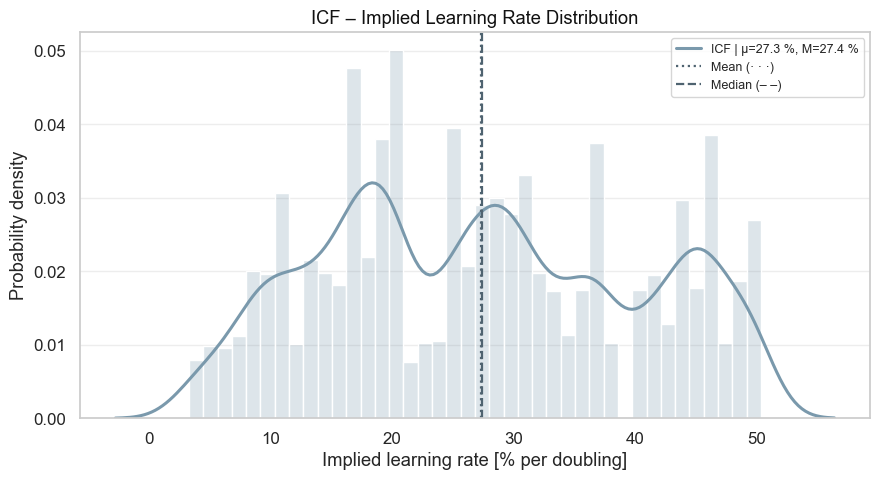

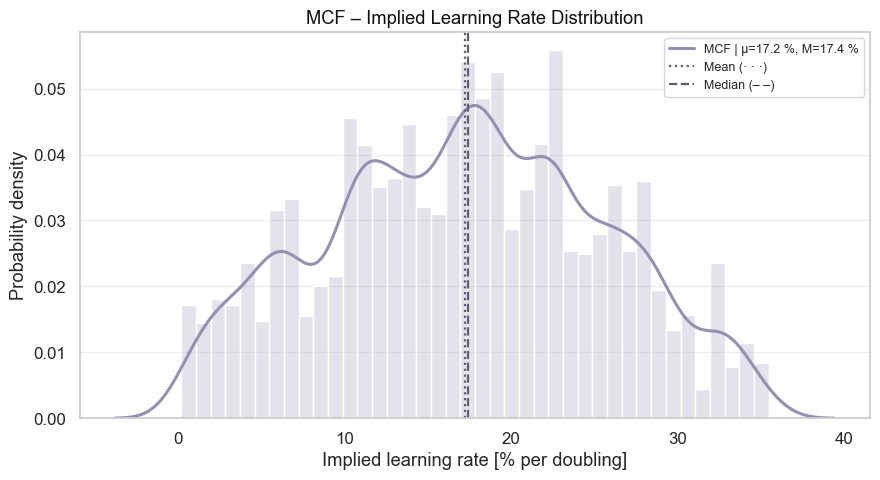

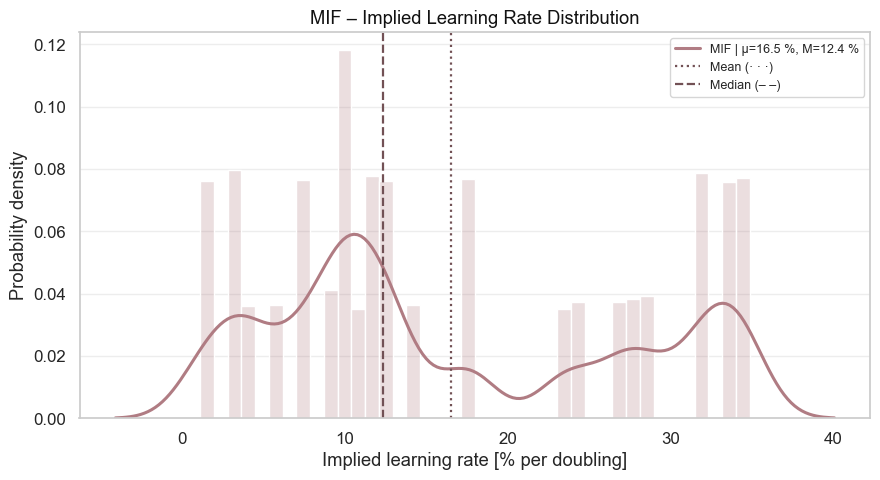

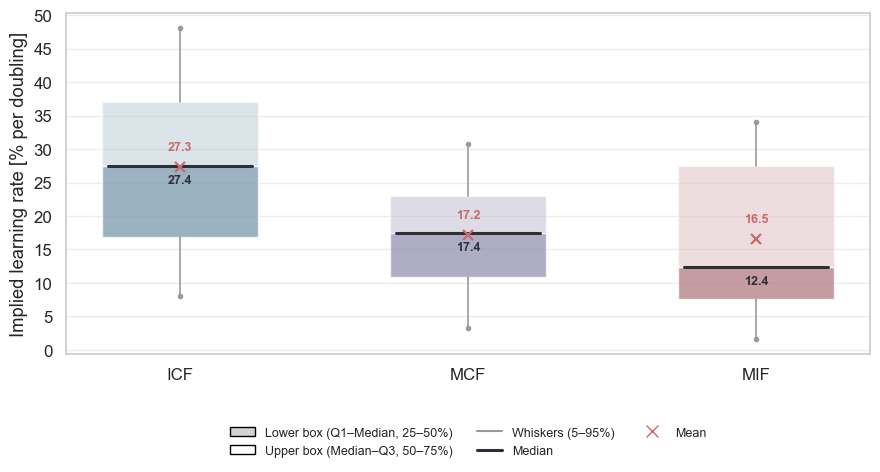

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import to_rgb

# =========================================================
# STYLE
# =========================================================
sns.set_theme(style="whitegrid", font_scale=1.1)
np.random.seed(42)

# =========================================================
# INPUT DATA (USD/kW)
# =========================================================

# -------- ICF --------
icf_foak = np.array([
    16173.7, 12320.4, 10189.4, 13163.5,
    17603.0, 15041.9, 8148.3, 10656.8,
    12086.5, 16656.1, 16868.4, 7948.1, 15135.6
])

icf_10oak = np.array([
    1718.2, 2196.6, 3883.7, 5067.7, 5746.8, 8298.7, 9123.0
])

# -------- MCF --------
mcf_foak = np.array([
    12441.3, 9477.2, 7838.0, 10125.8,
    13540.8, 11570.7, 6267.9, 8197.6,
    9297.3, 12812.4, 12975.7, 6113.9, 11642.8
])

mcf_10oak = np.array([
    9993.2, 10529.0, 5392.8, 4828.7, 5459.5, 7569.7,
    3161.4, 3439.0, 3489.4, 4289.6, 4991.0, 5024.2,
    5873.3, 6384.4, 6368.9, 7018.9, 4319.7, 4112.2,
    4154.5, 4182.2, 5745.4, 6058.9, 7604.7, 8202.5,
    6747.7, 5635.5, 6402.8, 6515.7, 6750.9, 8603.6,
    5575.9, 7924.9, 11735.0,
    # --- NEW: 
    5011.4, 4990.1, 5024.4, 3439.0, 3489.4,
    5872.1, 4291.3, 3161.7, 6385.5, 6269.7,
    6588.9, 4368.5, 7985.1, 6227.0, 4003.0,
    4930.4, 7781.6, 5422.6, 13440.5, 8732.1
])

# -------- MIF --------
mif_foak = np.array([
    18662.0, 14215.8, 11757.0, 15188.6,
    20311.2, 17356.1, 9401.9, 12296.3,
    13945.9, 19218.5, 19463.6, 9170.9, 17464.2
])

# min / mode / max
mif_10oak = np.array([4889.47, 12391.1, 13426.86])

# =========================================================
# LEARNING RATE FUNCTION
# =========================================================
def implied_lr(c1, c2, n1=1, n2=10):
    b = np.log(c2 / c1) / np.log(n2 / n1)
    return 1 - 2**b

# =========================================================
# MONTE CARLO SAMPLER (10,000 valid draws)
# =========================================================
def monte_carlo_lr(c_foak, c_10oak, n_iter=10_000):
    rng = np.random.default_rng()
    lr = []

    while len(lr) < n_iter:
        c1 = rng.choice(c_foak, size=n_iter)
        c2 = rng.choice(c_10oak, size=n_iter)
        mask = c2 < c1
        lr.extend(implied_lr(c1[mask], c2[mask]).tolist())

    return np.array(lr[:n_iter]) * 100  # %

# =========================================================
# RUN SIMULATIONS
# =========================================================
lr_data = {
    "ICF": monte_carlo_lr(icf_foak, icf_10oak),
    "MCF": monte_carlo_lr(mcf_foak, mcf_10oak),
    "MIF": monte_carlo_lr(mif_foak, mif_10oak)
}

# =========================================================
# COLORS
# =========================================================
box_colors = {
    "ICF_lower": "#7A99AC", "ICF_upper": "#BFCED6",
    "MCF_lower": "#9590B2", "MCF_upper": "#C2BFD3",
    "MIF_lower": "#B07C83", "MIF_upper": "#DFC2C3"
}

pdf_colors = {"ICF": "#7A99AC", "MCF": "#9590B2", "MIF": "#B07C83"}

MEAN_COLOR = "#c96a6a"
MEDIAN_COLOR = "#2F2F3A"
WHISKER_COLOR = "#9A9A9A"

def darken(color, factor=0.65):
    r, g, b = to_rgb(color)
    return (r * factor, g * factor, b * factor)

# =========================================================
# PDF + HISTOGRAM PLOTS
# =========================================================
for fam, data in lr_data.items():

    fig, ax = plt.subplots(figsize=(9, 5))
    base = pdf_colors[fam]
    line = darken(base)

    mean_val = np.mean(data)
    median_val = np.median(data)

    sns.histplot(data, bins=40, stat="density",
                 color=base, alpha=0.25, ax=ax)

    sns.kdeplot(data, color=base, lw=2.2, ax=ax)

    ax.axvline(mean_val, color=line, ls=":", lw=1.6)
    ax.axvline(median_val, color=line, ls="--", lw=1.6)

    ax.set_xlabel("Implied learning rate [% per doubling]")
    ax.set_ylabel("Probability density")
    ax.set_title(f"{fam} – Implied Learning Rate Distribution")

    legend_elements = [
        Line2D([0,1],[0,0], color=base, lw=2.2,
               label=f"{fam} | μ={mean_val:.1f} %, M={median_val:.1f} %"),
        Line2D([0,1],[0,0], color=line, ls=":", lw=1.6, label="Mean (· · ·)"),
        Line2D([0,1],[0,0], color=line, ls="--", lw=1.6, label="Median (– –)")
    ]

    ax.legend(handles=legend_elements, frameon=True, fontsize=9)
    ax.grid(axis="y", alpha=0.35)
    ax.grid(axis="x", visible=False)

    plt.tight_layout()
    plt.savefig(f"Implied_LearningRate_PDF_{fam}_updated.png",
                dpi=400, bbox_inches="tight")
    plt.show()

# =========================================================
# BOXPLOT (LCOE STYLE)
# =========================================================
fig, ax = plt.subplots(figsize=(9, 5))
order = ["ICF", "MCF", "MIF"]

for i, fam in enumerate(order):
    data = lr_data[fam]
    q1, q2, q3 = np.percentile(data, [25, 50, 75])
    wlow, whigh = np.percentile(data, [5, 95])
    mean_val = np.mean(data)

    ax.add_patch(Rectangle((i-0.27, q1), 0.54, q2-q1,
                           facecolor=box_colors[f"{fam}_lower"], alpha=0.75))
    ax.add_patch(Rectangle((i-0.27, q2), 0.54, q3-q2,
                           facecolor=box_colors[f"{fam}_upper"], alpha=0.55))

    ax.plot([i,i],[q3,whigh], color=WHISKER_COLOR, lw=1.2)
    ax.plot([i,i],[q1,wlow], color=WHISKER_COLOR, lw=1.2)
    ax.plot(i, wlow, "o", color=WHISKER_COLOR, ms=3)
    ax.plot(i, whigh, "o", color=WHISKER_COLOR, ms=3)

    ax.plot([i-0.25,i+0.25],[q2,q2], color=MEDIAN_COLOR, lw=2.2)
    ax.plot(i, mean_val, "x", color=MEAN_COLOR, ms=7, mew=1.6)

    ax.text(i, mean_val+2.5, f"{mean_val:.1f}",
            color=MEAN_COLOR, ha="center", fontsize=9, fontweight="bold")
    ax.text(i, q2-2.5, f"{q2:.1f}",
            color=MEDIAN_COLOR, ha="center", fontsize=9, fontweight="bold")

ax.set_xticks(range(3))
ax.set_xticklabels(order)
ax.set_ylabel("Implied learning rate [% per doubling]")
ax.yaxis.set_major_locator(MultipleLocator(5))
ax.grid(axis="y", alpha=0.35)
ax.grid(axis="x", visible=False)

legend_elements = [
    Rectangle((0,0),1,1, facecolor="lightgray", edgecolor="black",
              label="Lower box (Q1–Median, 25–50%)"),
    Rectangle((0,0),1,1, facecolor="white", edgecolor="black",
              label="Upper box (Median–Q3, 50–75%)"),
    Line2D([0,1],[0,0], color=WHISKER_COLOR, lw=1.5,
           label="Whiskers (5–95%)"),
    Line2D([0,1],[0,0], color=MEDIAN_COLOR, lw=2.2,
           label="Median"),
    Line2D([0],[0], marker="x", color=MEAN_COLOR,
           lw=0, markersize=8, label="Mean")
]

ax.legend(handles=legend_elements, loc="upper center",
          bbox_to_anchor=(0.5,-0.18), ncol=3,
          frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("Implied_LearningRate_Boxplot_FOAK_to_10thOAK_updated.png",
            dpi=400, bbox_inches="tight")
plt.show()
